# FB15k-237: independent baseline and five scratch architectures

Run cells in order. Select a GPU runtime before starting. The default research run
trains a 100-epoch full-data graph baseline and 15 pilot runs of 30 epochs each.
These are substantial experiments; smoke tests alone do not establish performance.

All task-specific parameters start from scratch. Only frozen RoBERTa uses pretrained
weights. User-selected budget: **5 structural warmup + 25 integrated epochs**;
`original-no-warmup` uses **30 integrated epochs**, with identical architecture.
Warmup uses the fixed learning rate, not a learning-rate scheduler. Pilot runs have
one optimizer step per epoch. Validation selects checkpoints and architectures.

Use a repository ref containing these changes. For a private repository, arrange
GitHub access or upload the repository first; do not paste access tokens into cells.
Completed compatible runs are verified and skipped. Interrupted runs resume from
their own `last.pt`; baseline/pilot weights never initialize other experiments.


## 1. Environment setup and GPU verification


In [12]:
import os
import sys
import subprocess
from pathlib import Path

os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')
os.environ.setdefault('PYTHONUNBUFFERED', '1')
import torch
print('Python:', sys.version)
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('CPU fallback active. Choose Runtime > Change runtime type > GPU for research training.')


Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


## 2. Clone repository and install dependencies


In [13]:
REPO_URL = 'https://github.com/Rashmika119/Research-project.git'
REPO_REF = 'feature/phase_03'  # Push these changes first; optionally use a fixed commit.
REPO_DIR = Path('/content/Research-project')
if not REPO_DIR.exists():
    subprocess.run(['git', 'clone', REPO_URL, str(REPO_DIR)], check=True)
    subprocess.run(['git', 'checkout', REPO_REF], cwd=REPO_DIR, check=True)
os.chdir(REPO_DIR)
assert Path('run_research_baseline.py').exists(), 'Checkout a ref containing the new scratch pipeline.'
subprocess.run([sys.executable, '-m', 'pip', 'install', '-r', 'requirements.txt'], check=True)
print('Repository commit:', subprocess.check_output(['git', 'rev-parse', 'HEAD'], text=True).strip())


Repository commit: c8d6638d654a8217d69d56ec014d4dcd3455d6f6


## 3. Mount Google Drive


In [14]:
from google.colab import drive
drive.mount('/content/drive')
RESEARCH_ROOT = Path('/content/drive/MyDrive/Research/scratch_pipeline_v1')
RESEARCH_ROOT.mkdir(parents=True, exist_ok=True)
# Configure before importing Transformers/Hub. Never memory-map weights on Drive.
LOCAL_HF_HOME = Path('/content/hf_cache')
os.environ['HF_HOME'] = str(LOCAL_HF_HOME)
os.environ['HF_HUB_CACHE'] = str(LOCAL_HF_HOME / 'hub')
os.environ['HUGGINGFACE_HUB_CACHE'] = str(LOCAL_HF_HOME / 'hub')
os.environ.pop('TRANSFORMERS_CACHE', None)
# Only verified files are copied to/from this persistent backup.
os.environ['RESEARCH_MODEL_BACKUP'] = str(RESEARCH_ROOT / 'verified_roberta_backup')
print('Local model cache:', os.environ['HF_HUB_CACHE'])
print('Verified Drive backup:', os.environ['RESEARCH_MODEL_BACKUP'])


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Local model cache: /content/hf_cache/hub
Verified Drive backup: /content/drive/MyDrive/Research/scratch_pipeline_v1/verified_roberta_backup


## 4. Configure paths, seeds, and training settings


In [15]:
import json
import yaml
import pandas as pd
from IPython.display import display

RUN_BASELINE = True
RUN_PILOT = True
RUN_FINAL_FULL_DATASET = False
RUN_OFFLINE_TESTS = True
RUN_REAL_LM_SMOKE = True
RUN_CUDA_RESUME_CHECK = True
RUN_REAL_LM_RESUME_CHECK = True
SKIP_COMPLETED = True
RESUME_INTERRUPTED = True
RUN_TAG = 'run2_verified'  # New code/RNG schema requires a new run, not an old checkpoint.

protocol = yaml.safe_load(Path('experiments/configs/research_protocol.yaml').read_text())
SEEDS = protocol['pilot']['seeds']
SUBSET_SEED = protocol['pilot']['subset_seed']
PILOT_ENTITIES = protocol['pilot']['max_entities']
PILOT_EPOCHS = protocol['pilot']['epochs']
WARMUP_EPOCHS = protocol['pilot']['warmup_epochs']
TEXT_BATCH_SIZE = protocol['pilot']['text_batch_size']
FINAL_EPOCHS = protocol['final']['epochs']
FINAL_SEED = protocol['final']['seed']

RAW_DIR = RESEARCH_ROOT / 'data' / 'fb15k237'
TEXT_DIR = RESEARCH_ROOT / 'data' / 'text'
POOLED_CACHE = RESEARCH_ROOT / 'pooled_text_cache'
RUN_ROOT = RESEARCH_ROOT / RUN_TAG
BASELINE_DIR = RUN_ROOT / 'baseline_full_seed0'
PILOT_DIR = RUN_ROOT / 'pilot_1000'
baseline_path = BASELINE_DIR / 'best.pt'  # Evaluation artifact only; never passed to variants.
RUN_ROOT.mkdir(parents=True, exist_ok=True)
from training.process import run_logged
from datetime import datetime
LOG_DIR = RUN_ROOT / 'logs' / datetime.now().strftime('%Y%m%d_%H%M%S_%f')
CPU_ENV = dict(os.environ, CUDA_VISIBLE_DEVICES='')
PRETRAINED_VERIFIED = False

def ensure_pretrained():
    global PRETRAINED_VERIFIED
    if not PRETRAINED_VERIFIED:
        run_logged([sys.executable, 'run_pretrained_check.py', '--device', 'cuda',
                    '--report', str(LOG_DIR / 'pretrained_report.json')], LOG_DIR / 'pretrained.log')
        PRETRAINED_VERIFIED = True

def launch(script, *arguments):
    # Also protects running an experiment cell directly without running test cells.
    ensure_pretrained()
    command = [sys.executable, script, *map(str, arguments)]
    if SKIP_COMPLETED:
        command.append('--skip-completed')
    if RESUME_INTERRUPTED:
        command.append('--resume')
    print('Starting:', script, flush=True)
    run_logged(command, LOG_DIR / (Path(script).stem + '.log'))

print('Pilot:', len(protocol['pilot']['variants']) * len(SEEDS), 'independent runs')
print('Budget:', WARMUP_EPOCHS, '+', PILOT_EPOCHS - WARMUP_EPOCHS,
      '; no-warmup:', PILOT_EPOCHS, 'integrated epochs')


Pilot: 15 independent runs
Budget: 5 + 25 ; no-warmup: 30 integrated epochs


## 5. Download and validate FB15k-237


In [16]:
from preprocessing.dataset import load_dataset
from preprocessing.graph_builder import build_train_graph, assert_no_leakage
from training.experiment_io import validate_fb15k237, prepare_data

dataset = load_dataset(RAW_DIR, download_if_missing=True, use_synthetic_fallback=False)
validate_fb15k237(dataset)
graph = build_train_graph(dataset.train, dataset.num_entities, dataset.num_relations)
assert_no_leakage(graph, dataset.train, dataset.valid, dataset.test)
print('Full dataset:', dataset.num_entities, 'entities;', dataset.num_relations, 'relations;',
      len(dataset.train), len(dataset.valid), len(dataset.test), 'train/valid/test')
# Each child verifies the shared manifest against these same original files.
pilot_data, _, _, pilot_manifest = prepare_data(str(RAW_DIR), PILOT_ENTITIES, SUBSET_SEED)
print('Pilot:', pilot_data.num_entities, 'entities;', len(pilot_data.train),
      len(pilot_data.valid), len(pilot_data.test), 'train/valid/test')
print('Pilot manifest SHA256:', pilot_manifest['sha256'])


Full dataset: 14541 entities; 237 relations; 272115 17535 20466 train/valid/test
Pilot: 1000 entities; 1022 55 86 train/valid/test
Pilot manifest SHA256: 01690d66958bac98fd28fc4452173de5362644216193e7ddb9c87eb952a52d31


## 6. Verify pretrained weights and run independent test groups
Preflight is mandatory before any experiment, even if optional smoke tests are off.
Offline regressions run in a CPU child process. The next cells independently test
actual pretrained RoBERTa and strict CUDA checkpoint resume. Explicit GPU requests
fail if CUDA is unavailable. Full logs and JSON diagnostics persist on Drive.
The resume diagnostic compares a second uninterrupted control as well as a resumed
run, including losses, weights, Adam state, RNG streams, progress and metrics.


In [17]:
if RUN_BASELINE or RUN_PILOT or RUN_FINAL_FULL_DATASET or RUN_REAL_LM_SMOKE or RUN_REAL_LM_RESUME_CHECK:
    ensure_pretrained()


Running: /usr/bin/python3 run_pretrained_check.py --device cuda --report /content/drive/MyDrive/Research/scratch_pipeline_v1/run2_verified/logs/20261010_053018_684230/pretrained_report.json
{
  "python": "3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]",
  "packages": {
    "torch": "2.11.0+cu130",
    "transformers": "5.18.0",
    "huggingface-hub": "1.33.0",
    "safetensors": "0.8.0",
    "torch-geometric": "2.8.0.post1"
  },
  "model": "roberta-base",
  "revision": "e2da8e2f811d1448a5b465c236feacd80ffbac7b",
  "cache": "/content/hf_cache/hub",
  "cache_environment": {
    "HF_HOME": "/content/hf_cache",
    "HF_HUB_CACHE": "/content/hf_cache/hub",
    "HUGGINGFACE_HUB_CACHE": "/content/hf_cache/hub",
    "TRANSFORMERS_CACHE": null,
    "RESEARCH_MODEL_BACKUP": "/content/drive/MyDrive/Research/scratch_pipeline_v1/verified_roberta_backup"
  }
}
{
  "verified_files": [
    {
      "path": "/content/hf_cache/hub/verified_snapshots/roberta-base/e2da8e2f811d1448a5b465c236feacd80ffbac7

In [18]:
import os
import sys
from pathlib import Path

# Run basic correctness checks
for script in (
    "run_tie_ranking_check.py",
    "run_complex_scorer_check.py"
):
    run_logged(
        [sys.executable, script],
        LOG_DIR / (Path(script).stem + ".log"),
        env=CPU_ENV
    )

# Run offline regression tests
if RUN_OFFLINE_TESTS:

    offline_env = CPU_ENV.copy()

    # Remove the real model backup only from the test environment
    offline_env.pop("RESEARCH_MODEL_BACKUP", None)

    run_logged(
        [
            sys.executable,
            "run_scratch_smoke_test.py",
            "--offline-only",
            "--device",
            "cpu"
        ],
        LOG_DIR / "offline_tests.log",
        env=offline_env
    )

print("All offline regression tests passed!")

Running: /usr/bin/python3 run_tie_ranking_check.py
Tie-aware ranking checks PASSED
Running: /usr/bin/python3 run_complex_scorer_check.py
ComplEx scorer checks PASSED
Running: /usr/bin/python3 run_scratch_smoke_test.py --offline-only --device cpu
Offline regression suite; device=cpu
test_fifteen_run_orchestrator_uses_scratch_cli (test_notebook.NotebookTests.test_fifteen_run_orchestrator_uses_scratch_cli) ... Running original, seed 0 (1/15)
Running original, seed 1 (2/15)
Running original, seed 2 (3/15)
Running residual, seed 0 (4/15)
Running residual, seed 1 (5/15)
Running residual, seed 2 (6/15)
Running no-refinement, seed 0 (7/15)
Running no-refinement, seed 1 (8/15)
Running no-refinement, seed 2 (9/15)
Running original-no-warmup, seed 0 (10/15)
Running original-no-warmup, seed 1 (11/15)
Running original-no-warmup, seed 2 (12/15)
Running residual-no-softprompt, seed 0 (13/15)
Running residual-no-softprompt, seed 1 (14/15)
Running residual-no-softprompt, seed 2 (15/15)
{
  "variants": 

In [19]:
# Real pretrained GPU forward/backward gate for all five architectures.
if RUN_REAL_LM_SMOKE:
    run_logged([sys.executable, 'run_scratch_smoke_test.py', '--real-lm-only', '--device', 'cuda'],
               LOG_DIR / 'real_roberta.log')


Running: /usr/bin/python3 run_scratch_smoke_test.py --real-lm-only --device cuda
Real frozen RoBERTa smoke tests on cuda (synthetic facts; no research metrics)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4185.64it/s]
[transformers] RobertaModel LOAD REPORT from: /content/hf_cache/hub/verified_snapshots/roberta-base/e2da8e2f811d1448a5b465c236feacd80ffbac7b
Key                       | Status     | 
--------------------------+------------+-
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
ori

In [20]:
# Dedicated CUDA resume verification; never covered up by the CPU test setting.
DIAGNOSTIC_DIR = RUN_ROOT / 'diagnostics' / datetime.now().strftime('%Y%m%d_%H%M%S_%f')
if RUN_CUDA_RESUME_CHECK:
    from run_pretrained_check import select_device
    select_device('cuda')
    for repeat in range(3):
        run_logged([sys.executable, '-m', 'unittest',
                    'tests.test_research_pipeline.PipelineTests.test_resume_matches_uninterrupted', '-v'],
                   LOG_DIR / f'cuda_resume_targeted_{repeat}.log')
    run_logged([sys.executable, 'run_resume_diagnostic.py', '--device', 'cuda', '--repeats', '3',
                '--output-dir', str(DIAGNOSTIC_DIR / 'tiny_lm')], LOG_DIR / 'cuda_resume.log')


Running: /usr/bin/python3 -m unittest tests.test_research_pipeline.PipelineTests.test_resume_matches_uninterrupted -v
test_resume_matches_uninterrupted (tests.test_research_pipeline.PipelineTests.test_resume_matches_uninterrupted) ... Device: cuda; variant=original; initialization=scratch
Data: 12 entities, 35/5/5 train/valid/test
Budget: 1 structural + 2 main epochs; 3 optimizer steps; fixed lr=0.001
Epoch 001/3 | structural_warmup | loss=1.386012 | val_MRR=0.226313
Initial integrated validation: {'MRR': 0.43166667222976685, 'Hits@1': 0.30000001192092896, 'Hits@3': 0.4000000059604645, 'Hits@10': 1.0, 'Optimistic_MRR': 0.43166667222976685, 'Tie_query_fraction': 0.0, 'Mean_tied_candidates': 1.0, 'Max_tied_candidates': 1}
Epoch 002/3 | main | loss=1.386570 | val_MRR=0.365000
Epoch 003/3 | main | loss=1.384364 | val_MRR=0.362619
Best epoch: 1 | validation: {'MRR': 0.43166667222976685, 'Hits@1': 0.30000001192092896, 'Hits@3': 0.4000000059604645, 'Hits@10': 1.0, 'Optimistic_MRR': 0.43166667

In [21]:
# A separate real-RoBERTa GPU training interruption/resume experiment.
if RUN_REAL_LM_RESUME_CHECK:
    run_logged([sys.executable, 'run_resume_diagnostic.py', '--device', 'cuda', '--real-lm',
                '--variant', 'residual', '--repeats', '1',
                '--output-dir', str(DIAGNOSTIC_DIR / 'real_roberta')], LOG_DIR / 'real_roberta_resume.log')


Running: /usr/bin/python3 run_resume_diagnostic.py --device cuda --real-lm --variant residual --repeats 1 --output-dir /content/drive/MyDrive/Research/scratch_pipeline_v1/run2_verified/diagnostics/20261010_053149_027486/real_roberta
Device: cuda; variant=residual; initialization=scratch
Data: 12 entities, 35/5/5 train/valid/test

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 2819.09it/s]
[transformers] RobertaModel LOAD REPORT from: /content/hf_cache/hub/verified_snapshots/roberta-base/e2da8e2f811d1448a5b465c236feacd80ffbac7b
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architectu

## 7. Train or load the independent graph-only baseline
Full FB15k-237, RGAT + ComplEx, width 32, 100 epochs, four negatives, fixed LR 0.001.
Validation runs every five epochs. A compatible completed run is loaded by verified
skip; a bare historical `.pt` file lacks this experiment's history/provenance and is
not silently treated as a completed run. Checkpoints go directly to Drive each epoch.


In [22]:
if RUN_BASELINE:
    launch('run_research_baseline.py', '--output-dir', BASELINE_DIR, '--raw-dir', RAW_DIR,
           '--epochs', protocol['baseline']['epochs'], '--lr', protocol['baseline']['lr'],
           '--num-negatives', protocol['baseline']['num_negatives'],
           '--train-batch-size', protocol['baseline']['train_batch_size'],
           '--eval-every', protocol['baseline']['eval_every'])


Starting: run_research_baseline.py
Running: /usr/bin/python3 run_research_baseline.py --output-dir /content/drive/MyDrive/Research/scratch_pipeline_v1/run2_verified/baseline_full_seed0 --raw-dir /content/drive/MyDrive/Research/scratch_pipeline_v1/data/fb15k237 --epochs 100 --lr 0.001 --num-negatives 4 --train-batch-size 32768 --eval-every 5 --skip-completed --resume
Device: cuda; variant=baseline; initialization=scratch
Data: 14541 entities, 272115/17535/20466 train/valid/test
Budget: 0 structural + 100 main epochs; 900 optimizer steps; fixed lr=0.001
Epoch 001/100 | main | loss=1.386293
Epoch 002/100 | main | loss=1.386282
Epoch 003/100 | main | loss=1.386240
Epoch 004/100 | main | loss=1.386115
Epoch 005/100 | main | loss=1.385763 | val_MRR=0.048846
Epoch 006/100 | main | loss=1.384758
Epoch 007/100 | main | loss=1.381786
Epoch 008/100 | main | loss=1.372773
Epoch 009/100 | main | loss=1.345218
Epoch 010/100 | main | loss=1.276143 | val_MRR=0.060061
Epoch 011/100 | main | loss=1.1925

## 8. Save and evaluate baseline results


In [23]:
baseline_results_file = BASELINE_DIR / 'results.json'
baseline_result = json.loads(baseline_results_file.read_text()) if baseline_results_file.exists() else None
if baseline_result:
    assert baseline_result['dataset_scope'] == 'full'
    assert baseline_result['ranking_policy'] == 'average_exact_ties'
    display(pd.DataFrame([{'split': split, **baseline_result[split]}
                          for split in ('validation', 'test')]))
    print('Best epoch:', baseline_result['best_epoch'], '; checkpoint:', baseline_path)
else:
    print('No baseline result yet. Scratch pilot models can still run independently.')


,split,MRR,Hits@1,Hits@3,Hits@10,Optimistic_MRR,Tie_query_fraction,Mean_tied_candidates,Max_tied_candidates
0,validation,0.150916,0.084232,0.153892,0.289649,0.150916,0.000855,1.026461,67
1,test,0.150322,0.084066,0.154525,0.286597,0.150322,0.001515,1.039847,67


Best epoch: 100 ; checkpoint: /content/drive/MyDrive/Research/scratch_pipeline_v1/run2_verified/baseline_full_seed0/best.pt


## 9. Configure the five variants from scratch
All variants use fresh entity/relation tables, first RGAT and other trainable modules.
`original-no-warmup` has exactly the same architecture as `original`.
`residual-no-softprompt` retains second RGAT and refinement residual, uses masked
mean text pooling, and caches only frozen 768-wide vectors, never projected vectors.
The baseline checkpoint is deliberately absent from the command below.


In [24]:
display(pd.DataFrame([
    {'variant': 'original', 'soft_prompt': True, 'residual': False, 'second_RGAT': True, 'warmup': WARMUP_EPOCHS},
    {'variant': 'residual', 'soft_prompt': True, 'residual': True, 'second_RGAT': True, 'warmup': WARMUP_EPOCHS},
    {'variant': 'no-refinement', 'soft_prompt': True, 'residual': True, 'second_RGAT': False, 'warmup': WARMUP_EPOCHS},
    {'variant': 'original-no-warmup', 'soft_prompt': True, 'residual': False, 'second_RGAT': True, 'warmup': 0},
    {'variant': 'residual-no-softprompt', 'soft_prompt': False, 'residual': True, 'second_RGAT': True, 'warmup': WARMUP_EPOCHS},
]))


,variant,soft_prompt,residual,second_RGAT,warmup
0,original,True,False,True,5
1,residual,True,True,True,5
2,no-refinement,True,True,False,5
3,original-no-warmup,True,False,True,0
4,residual-no-softprompt,False,True,True,5


## 10. Execute all three seeds per variant
Fifteen sequential child processes release GPU memory between runs. The same subset
manifest and candidate set are verified for every run. Use the same command to resume
after a disconnect. Changing settings requires a new RUN_TAG.


In [25]:
if RUN_PILOT:
    launch('run_phase5_comparisons.py', '--output-dir', PILOT_DIR,
           '--max-entities', PILOT_ENTITIES, '--epochs', PILOT_EPOCHS,
           '--warmup-epochs', WARMUP_EPOCHS, '--subset-seed', SUBSET_SEED,
           '--seeds', *SEEDS, '--raw-dir', RAW_DIR, '--text-dir', TEXT_DIR,
           '--cache-dir', POOLED_CACHE, '--text-batch-size', TEXT_BATCH_SIZE)


Starting: run_phase5_comparisons.py
Running: /usr/bin/python3 run_phase5_comparisons.py --output-dir /content/drive/MyDrive/Research/scratch_pipeline_v1/run2_verified/pilot_1000 --max-entities 1000 --epochs 30 --warmup-epochs 5 --subset-seed 0 --seeds 0 1 2 --raw-dir /content/drive/MyDrive/Research/scratch_pipeline_v1/data/fb15k237 --text-dir /content/drive/MyDrive/Research/scratch_pipeline_v1/data/text --cache-dir /content/drive/MyDrive/Research/scratch_pipeline_v1/pooled_text_cache --text-batch-size 4 --skip-completed --resume
Running original, seed 0 (1/15)
[entity-text] downloading short entity text...
[entity-text] downloading long entity descriptions...
[relation-text] downloading relation descriptions...
Device: cuda; variant=original; initialization=scratch
Data: 1000 entities, 1022/55/86 train/valid/test

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 3554.10it/s]
[transformers] RobertaModel LOAD REPORT from: /content/hf_cache/hub/verified_snapshots/roberta-base/e2da8

## 11. Individual checkpoints and histories


In [26]:
run_files = sorted(PILOT_DIR.glob('*_seed*/results.json'))
artifact_rows = []
for file in run_files:
    r = json.loads(file.read_text())
    artifact_rows.append({'variant': r['settings']['variant'], 'seed': r['settings']['seed'],
        'best_epoch': r['best_epoch'], 'warmup_epochs': r['warmup_epochs'], 'main_epochs': r['main_epochs'],
        'optimizer_steps': r['optimizer_steps'], 'duration_seconds': r['duration_seconds'],
        'peak_GPU_GiB': (r['peak_gpu_memory_bytes'] / 2**30) if r['peak_gpu_memory_bytes'] is not None else None,
        'checkpoint': str(file.parent / 'best.pt')})
display(pd.DataFrame(artifact_rows))
print('Every run saves config.json, manifest.json, best.pt, last.pt, history.json/CSV, metrics.csv and results.json.')


,variant,seed,best_epoch,warmup_epochs,main_epochs,optimizer_steps,duration_seconds,peak_GPU_GiB,checkpoint
0,no-refinement,0,25,5,25,30,756.183985,0.661099,/content/drive/MyDrive/Research/scratch_pipeli...
1,no-refinement,1,5,5,25,30,753.427429,0.661099,/content/drive/MyDrive/Research/scratch_pipeli...
2,no-refinement,2,9,5,25,30,750.056994,0.661099,/content/drive/MyDrive/Research/scratch_pipeli...
3,original-no-warmup,0,18,0,30,30,907.075588,0.676743,/content/drive/MyDrive/Research/scratch_pipeli...
4,original-no-warmup,1,22,0,30,30,901.829832,0.676743,/content/drive/MyDrive/Research/scratch_pipeli...
5,original-no-warmup,2,14,0,30,30,904.459266,0.676743,/content/drive/MyDrive/Research/scratch_pipeli...
6,original,0,25,5,25,30,757.561660,0.676743,/content/drive/MyDrive/Research/scratch_pipeli...
7,original,1,25,5,25,30,754.673992,0.676743,/content/drive/MyDrive/Research/scratch_pipeli...
8,original,2,15,5,25,30,757.399374,0.676743,/content/drive/MyDrive/Research/scratch_pipeli...
9,residual-no-softprompt,0,19,5,25,30,26.643494,0.513167,/content/drive/MyDrive/Research/scratch_pipeli...


Every run saves config.json, manifest.json, best.pt, last.pt, history.json/CSV, metrics.csv and results.json.


## 12. Compare validation results


In [27]:
summary_file = PILOT_DIR / 'summary.json'
summary = json.loads(summary_file.read_text()) if summary_file.exists() else None
if summary:
    comparison = pd.read_csv(PILOT_DIR / 'comparison.csv')
    display(comparison.sort_values('validation_MRR_mean', ascending=False))
else:
    print('The comparison report appears only after all configured pilot runs finish.')


,variant,seeds,validation_MRR_mean,validation_MRR_std,validation_Hits@1_mean,validation_Hits@1_std,validation_Hits@3_mean,validation_Hits@3_std,validation_Hits@10_mean,validation_Hits@10_std,...,test_MRR_std,test_Hits@1_mean,test_Hits@1_std,test_Hits@3_mean,test_Hits@3_std,test_Hits@10_mean,test_Hits@10_std,best_epochs,duration_seconds_mean,peak_gpu_memory_bytes_max
1,residual,"0,1,2",0.089722,0.020507,0.063636,0.031492,0.103030,0.005249,0.136364,0.009091,...,0.026901,0.071705,0.032021,0.116279,0.025342,0.162791,0.025342,"30,5,30",755.056774,726653440
4,residual-no-softprompt,"0,1,2",0.089023,0.015893,0.069697,0.013887,0.087879,0.013887,0.130303,0.022878,...,0.008785,0.081395,0.011628,0.106589,0.008881,0.153101,0.006713,"19,7,26",21.410712,551009280
2,no-refinement,"0,1,2",0.080655,0.019172,0.048485,0.029223,0.090909,0.009091,0.133333,0.005249,...,0.022437,0.067829,0.026217,0.100775,0.018689,0.156977,0.020963,"25,5,9",753.222802,709849600
0,original,"0,1,2",0.065383,0.016085,0.036364,0.000000,0.081818,0.041660,0.118182,0.032778,...,0.014248,0.027132,0.006713,0.075581,0.041925,0.147287,0.038711,"25,25,15",756.545009,726647296
3,original-no-warmup,"0,1,2",0.063390,0.004914,0.033333,0.005249,0.075758,0.005249,0.115152,0.005249,...,0.005839,0.021318,0.014631,0.073643,0.016783,0.139535,0.020140,"18,22,14",904.454895,726647296


## 13. Select the best variant using mean validation MRR only


In [28]:
selected_variant = summary['selected_by_validation'] if summary else None
print('Selected architecture:', selected_variant)
if summary:
    assert summary['selection_metric'] == 'mean validation MRR'
    print('Seeds:', summary['seeds'])
    print('Pilot candidates:', PILOT_ENTITIES, '; full-data candidates:', dataset.num_entities)
    print('Do not compare pilot MRR directly with full-dataset baseline MRR.')


Selected architecture: residual
Seeds: [0, 1, 2]
Pilot candidates: 1000 ; full-data candidates: 14541
Do not compare pilot MRR directly with full-dataset baseline MRR.


## 14. Visualize training loss and validation MRR


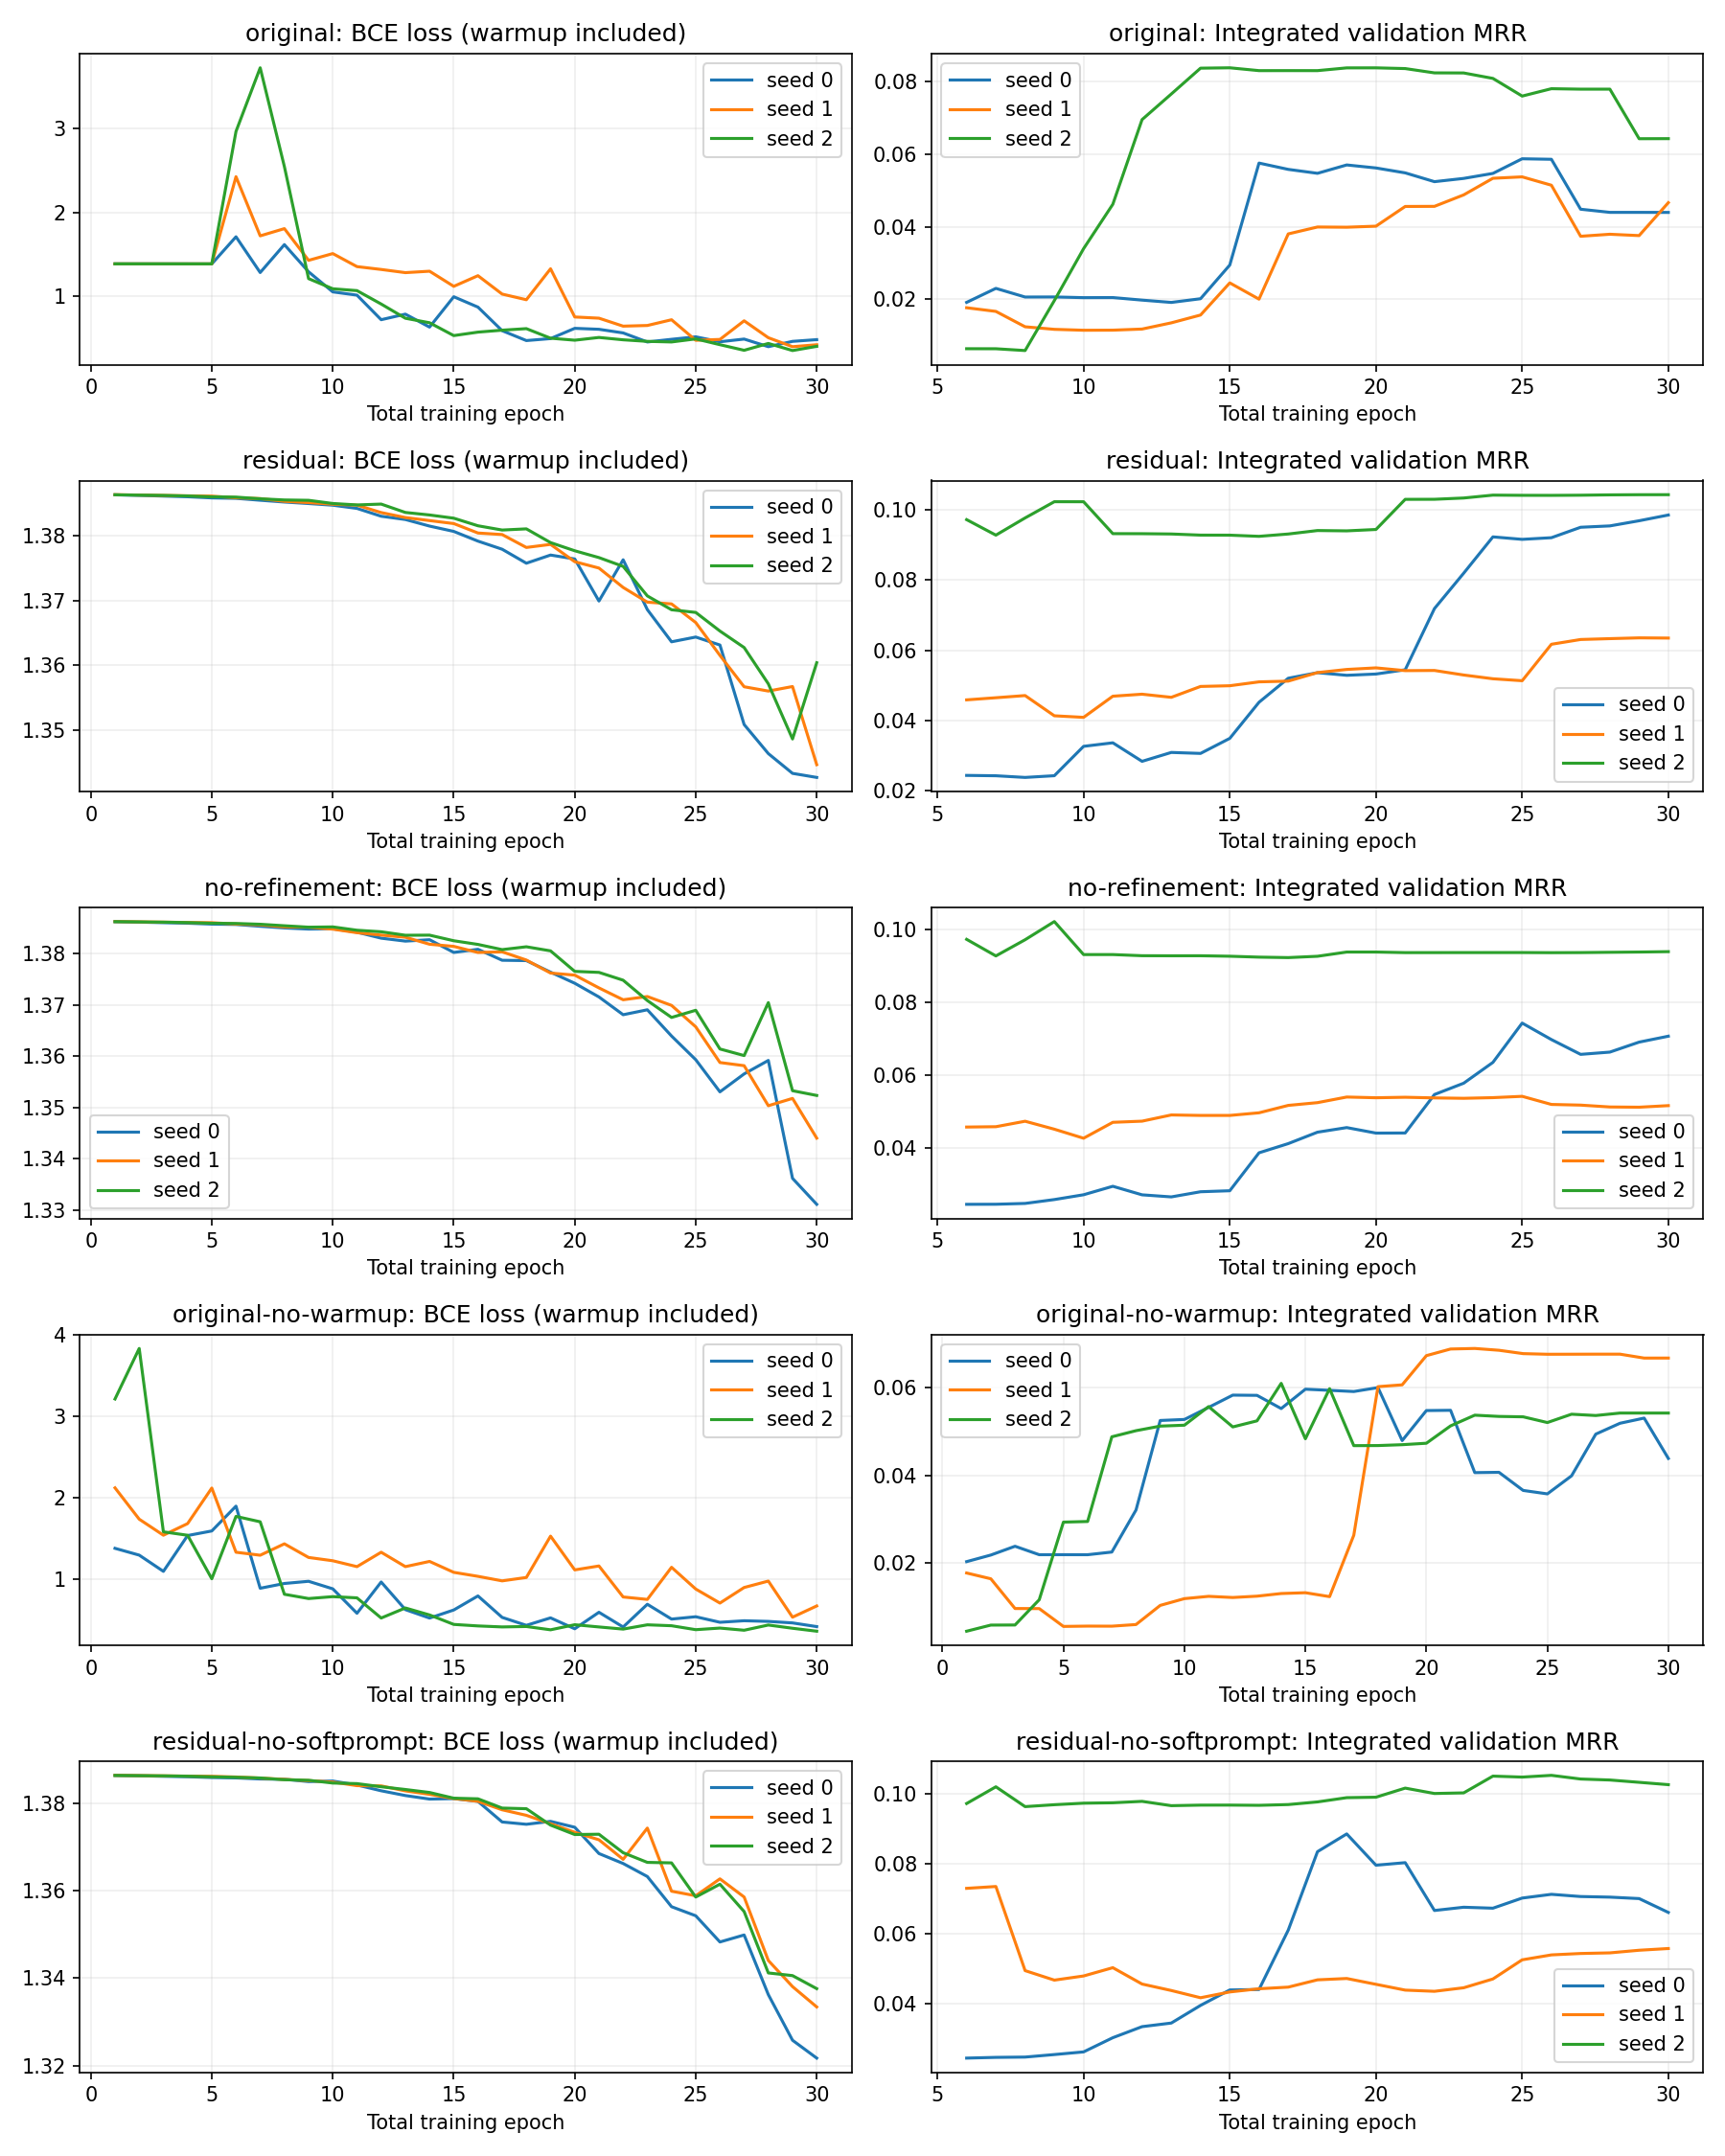

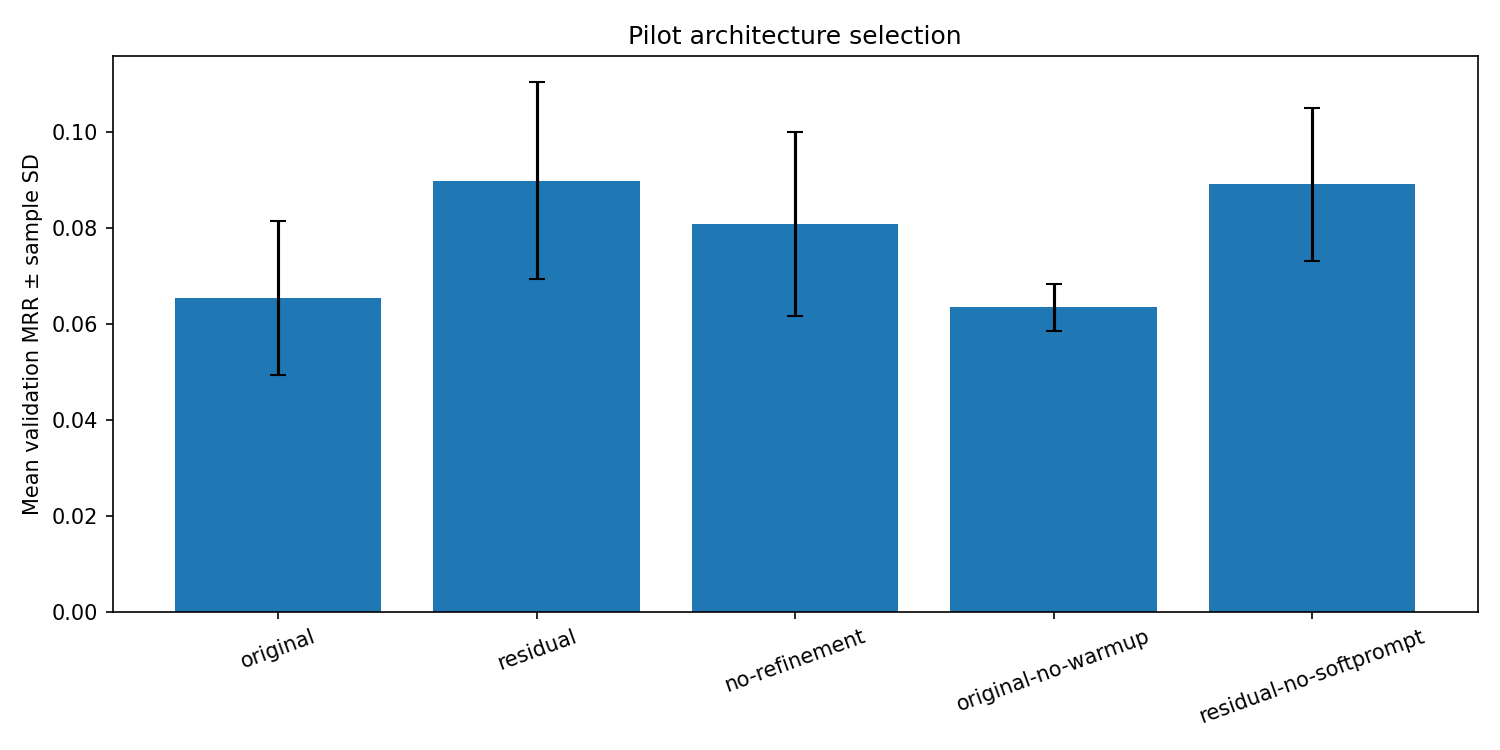

Warmup loss is included in loss curves; validation curves use the integrated model only.


In [29]:
from IPython.display import Image, display
if summary:
    display(Image(filename=str(PILOT_DIR / 'training_curves.png')))
    display(Image(filename=str(PILOT_DIR / 'validation_comparison.png')))
print('Warmup loss is included in loss curves; validation curves use the integrated model only.')


## 15. Optional full-dataset training of the selected architecture
Disabled by default. This creates a fresh model with full-data entity/relation tables.
No pilot or baseline checkpoint is passed. The flag does not guarantee that a full
two-RGAT + RoBERTa training graph fits a T4. Start with text batch size 1 if needed;
text batching cannot remove full-graph RGAT memory costs. A larger GPU may be needed.
There is no automatic dimension reduction, sampling, precision change, or objective change.
The default final budget is 100 total epochs, including five warmup epochs if applicable.


In [30]:
FINAL_DIR = RUN_ROOT / 'final_full' / f'{selected_variant}_seed{FINAL_SEED}' if selected_variant else None
if RUN_FINAL_FULL_DATASET:
    assert selected_variant is not None, 'Finish all pilot runs and validation selection first.'
    launch('run_phase5_training.py', '--variant', selected_variant, '--max-entities', 0,
           '--epochs', FINAL_EPOCHS, '--warmup-epochs', WARMUP_EPOCHS, '--seed', FINAL_SEED,
           '--raw-dir', RAW_DIR, '--text-dir', TEXT_DIR, '--cache-dir', POOLED_CACHE,
           '--text-batch-size', TEXT_BATCH_SIZE, '--eval-every', protocol['final']['eval_every'],
           '--output-dir', FINAL_DIR)


## 16. Final evaluation and result export
Only compare full-dataset scores with full-dataset scores. Both models select checkpoints
using validation, then evaluate the untouched original test split. The export records
optimizer-step budgets because baseline minibatches and full-model full-batch training
have different update counts. Pilot architecture selection uses one fixed subset and
three seeds; the optional final run has one seed and is not a full multi-seed benchmark.


In [31]:
from training.reports import final_comparison

final_result_file = FINAL_DIR / 'results.json' if FINAL_DIR else None
if final_result_file and final_result_file.exists():
    assert baseline_result is not None, 'Train/load the independent full baseline for final comparison.'
    final_result = json.loads(final_result_file.read_text())
    rows = final_comparison(baseline_result, final_result, RUN_ROOT / 'exports')
    display(pd.DataFrame(rows))
else:
    print('Final full-data experiment is disabled or incomplete; no full-model benchmark claimed.')

with (RUN_ROOT / 'environment.txt').open('w') as environment_file:
    subprocess.run([sys.executable, '-m', 'pip', 'freeze'], stdout=environment_file, check=True)
print('Persistent artifacts:', RUN_ROOT)
print('Pilot CSV/JSON and PNG files:', PILOT_DIR)


Final full-data experiment is disabled or incomplete; no full-model benchmark claimed.
Persistent artifacts: /content/drive/MyDrive/Research/scratch_pipeline_v1/run2_verified
Pilot CSV/JSON and PNG files: /content/drive/MyDrive/Research/scratch_pipeline_v1/run2_verified/pilot_1000
